In [1]:
#!pip install pandas astroquery astropy numpy matplotlib scipy PyAstronomy
#Starting with the imports for all the different functions that will be used in this script and defining a defualt folder for saving plots
"""import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from scipy.optimize import curve_fit
from astropy.timeseries import LombScargle
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from PyAstronomy.pyTiming import pyPDM
"""
#Default folder for saving plots


In [1]:
#Now importing the mean and epoch photomotry, the gaia input, and the sys module to add the path to the gaiadr3_analysis folder
default_folder = "plots"  
import os
#NOTE CHANGE THIS TO THE PATH TO THE GITHUB FOLDER ON YOUR COMPUTER
os.chdir("C:/Users/matth/USRA2026/gaiadr3-analysis")
!pip install -e .
import gaiadr3_analysis.gaia_input as gi
import gaiadr3_analysis.mean_photometry as mphot
import gaiadr3_analysis.epoch_photometry as ephot

Obtaining file:///C:/Users/matth/USRA2026/gaiadr3-analysis
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for gaiadr3-analysis (pyproject.toml): started
  Building editable for gaiadr3-analysis (pyproject.toml): finished with status 'done'
  Created wheel for gaiadr3-analysis: filename=gaiadr3_analysis-0.1.0-0.editable-py3-none-any.whl size=11445 sha256=5bc5d94e9f4d5bd3ddfeed4477d4dccc3c8e88a90d022489f45d1f9018117b80
  Stored in directory: C:\Users\matth\AppData\Local\Temp\pip-ephem-wheel-cache-kkzw2717\wheels\54\df\34\0c3b5a


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Maintenance with possible short-time disconnections: 29 June 2026 18:00–20:00 CEST


In [2]:
#quering the Mean photometry data for the Gaia DR3 database for the stars in the MeMis survey
source_ids = (
4146594906281066368, 418001477279154304, 181233674136088960,
3211026372078082048, 3220757015623151616, 3017360348171372672,
3209634905754969856, 3017364063330718080, 3017367396223983616,
3216486478101981056, 3224479171721217280, 3217413606922372992,
3326710010525962624, 2922367976673391232, 5517239366958299776,
5513811055342280448, 817013387993056640, 5338490937045044096,
5336220823491735680, 3667302325846472320, 6116497702589633152,
6005290206037557760, 6044420729667868928, 4371780385208211584,
6730764715540788352, 2032810465079954944, 2059130368252069888,
2270245431209611776, 2272185759996420992, 1796736625538995072,
3131334452194616192
)

id_list = ", ".join(str(s) for s in source_ids)

adql = f"""
SELECT source_id, designation, ra, dec, parallax,
pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag,
phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE source_id IN ({id_list})
"""

df = gi.query_by_adql(adql)
print(f"Retrieved {len(df)} stars")
df.head()

Retrieved 31 stars


,source_id,designation,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
0,3667302325846472320,Gaia DR3 3667302325846472320,213.065666,2.409310,13.228111,-42.904556,-26.792411,4.961365,4.911909,5.030709
1,817013387993056640,Gaia DR3 817013387993056640,138.450704,43.217689,5.268664,-30.236426,-32.032132,5.241456,5.199314,5.340267
2,418001477279154304,Gaia DR3 418001477279154304,9.242984,53.896868,6.665666,17.444071,-9.522631,3.664362,3.552869,3.813564
3,6116497702589633152,Gaia DR3 6116497702589633152,215.759187,-39.511910,8.328745,-24.420861,-20.695946,4.362966,4.268634,4.533859
4,5338490937045044096,Gaia DR3 5338490937045044096,166.524167,-59.949865,2.157248,-10.210750,3.200785,6.669657,6.582181,6.798117


Plot saved as presentation_plots\ra_vs_dec1.pdf


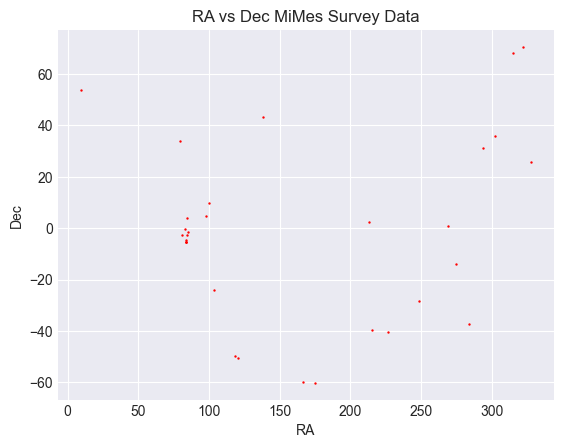

Plot saved as presentation_plots\pmra_vs_pmdec1.pdf


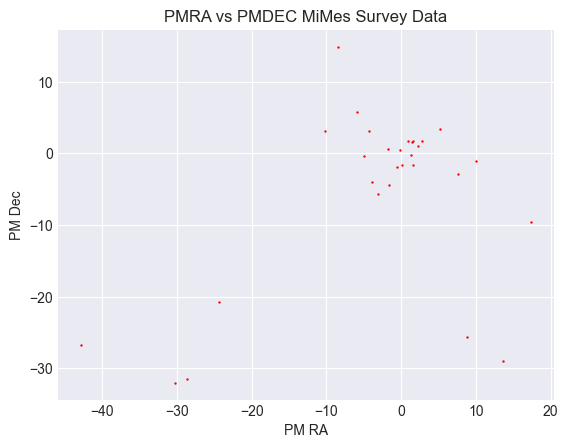

Plot saved as presentation_plots\hr_diagram1.pdf


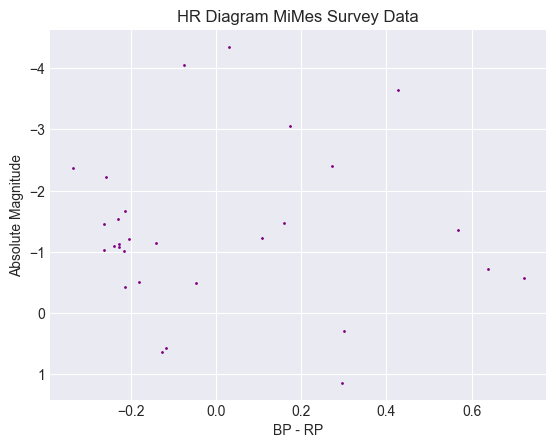

Plot saved as presentation_plots\hist1.pdf


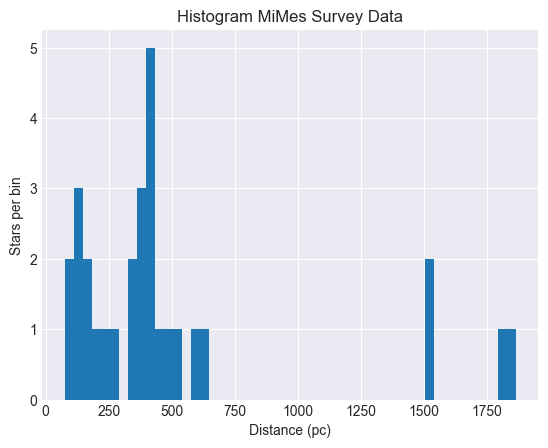

Distance, meidian: 392.72490131328766
Standard Deviation: 502.25004095572876
Plot saved as presentation_plots\fitted_hist1.pdf


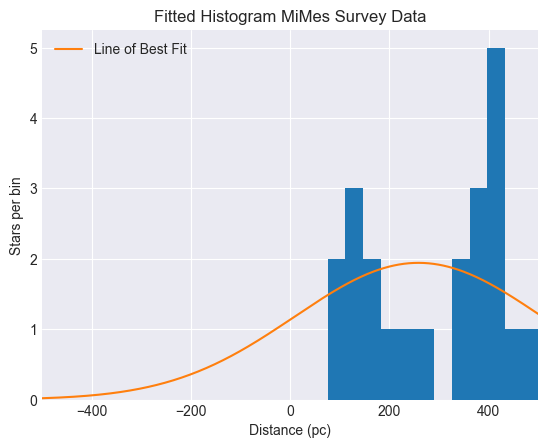

In [3]:
#Calling and saving all plots and functions from the MeMis survey data to a folder called plots in the mean photometry category. 

mphot.ra_vs_dec(df, save_plot=True, save_title="ra_vs_dec1", save_folder="presentation_plots",plot_title="RA vs Dec MiMes Survey Data")
mphot.pmra_vs_pmdec(df, save_plot=True, save_title="pmra_vs_pmdec1", save_folder="presentation_plots",plot_title="PMRA vs PMDEC MiMes Survey Data")
mphot.plot_hr_diagram(df, save_plot=True, save_title="hr_diagram1", save_folder="presentation_plots",plot_title="HR Diagram MiMes Survey Data")
mphot.hist(dists=df['parallax'], parallax=True, save_plot=True, save_title="hist1", save_folder="presentation_plots",plot_title="Histogram MiMes Survey Data")
mphot.fittedHist(dists=df['parallax'], parallax=True, save_plot=True, save_title="fitted_hist1", save_folder="presentation_plots",plot_title="Fitted Histogram MiMes Survey Data")

Len g, bp, and rp datasets respectively: 15, 15, 15
Plot saved as presentation_plots\light_curve1.pdf


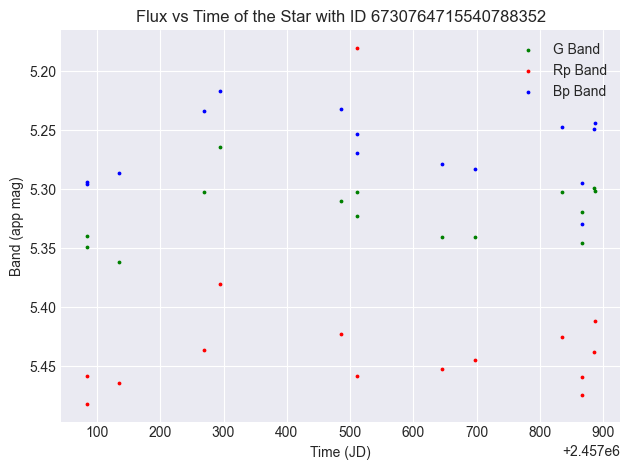

Best period: 668.246094 days (16037.906 hours)
Plot saved as presentation_plots\ls_plot1.pdf


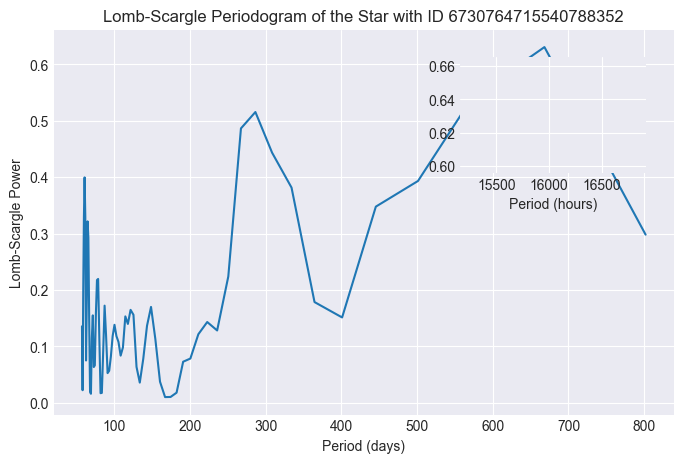

Best period = 0.1012145748987858 days
Plot saved as presentation_plots\pdm_plot1.pdf


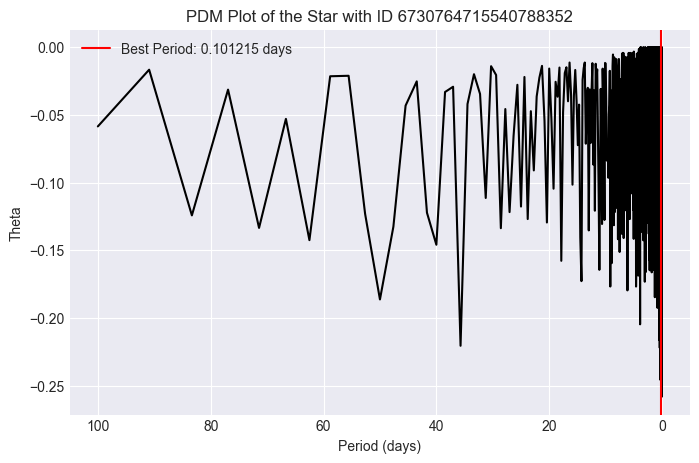

,frequency,theta
0,0.010,-0.058588
1,0.011,-0.016701
2,0.012,-0.124276
3,0.013,-0.031407
4,0.014,-0.133533
...,...,...
9986,9.996,-0.037568
9987,9.997,-0.038086
9988,9.998,-0.006582
9989,9.999,-0.162256


In [4]:
#Calling and saving all plots and functions from the MeMis survey data to a folder called plots in the epoch photometry category.

#Using a data link and retrieving the epoch photometry data from the star with ID 6730764715540788352 from the MeMis survey

df_datalink = gi.query_by_datalink(6730764715540788352)[6730764715540788352]

ephot.lightcurve(df_datalink, save_plot=True, save_title="light_curve1", save_folder="presentation_plots",plot_title="Flux vs Time of the Star with ID 6730764715540788352")
ephot.lomb_scargle(df_datalink['g_transit_time'], df_datalink['g_transit_mag'], plot = True, save_plot = True, plot_title="Lomb-Scargle Periodogram of the Star with ID 6730764715540788352", save_title="ls_plot1", save_folder="presentation_plots")
ephot.pdm(df_datalink['g_transit_time'], df_datalink['g_transit_mag'], plot = True, save_plot = True, plot_title="PDM Plot of the Star with ID 6730764715540788352", save_title="pdm_plot1", save_folder="presentation_plots")